# 24 · Árboles de Decisión — ¿Quién aprueba el examen?

**Pregunta:** dado cuántas horas estudió y cuántas horas durmió un estudiante,
¿puede una máquina aprender a predecir si va a aprobar?

Un árbol de decisión responde exactamente eso haciendo preguntas tipo *sí/no*:
¿estudió más de X horas? ¿durmió más de Y horas? Cada pregunta es un **split**;
el conjunto de preguntas forma el árbol.

Exploraremos qué pasa cuando el árbol hace **muy pocas preguntas** (demasiado simple)
vs **demasiadas** (memoriza el entrenamiento pero falla en datos nuevos).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(42)

## 1 · El dataset — 120 estudiantes

Simulamos 120 estudiantes con dos medidas:

| Variable | Qué mide | Rango |
|---|---|---|
| `horas_estudio` | Horas de estudio el día anterior | 0 – 10 h |
| `horas_sueno` | Horas de sueño la noche anterior | 3 – 10 h |
| `aprueba` | ¿Aprobó? | 1 = sí / 0 = no |

**Regla que usamos para generar los datos:**
aprueba si `horas_estudio ≥ 4 AND horas_sueno ≥ 6`, con ruido del 15 %.

In [2]:
N = 120
horas_estudio = rng.uniform(0, 10, N)
horas_sueno   = rng.uniform(3, 10, N)

aprueba_base = ((horas_estudio >= 4) & (horas_sueno >= 6)).astype(int)
ruido        = rng.random(N) < 0.15
aprueba      = np.where(ruido, 1 - aprueba_base, aprueba_base)

df = pd.DataFrame({
    "horas_estudio": horas_estudio.round(1),
    "horas_sueno":   horas_sueno.round(1),
    "aprueba":       aprueba,
})

print(f"Total estudiantes : {N}")
print(f"Aprueba (1)       : {aprueba.sum()} ({aprueba.mean():.0%})")
print(f"Reprueba (0)      : {(1-aprueba).sum()} ({1-aprueba.mean():.0%})")
df.head()

Total estudiantes : 120
Aprueba (1)       : 50 (42%)
Reprueba (0)      : 70 (58%)


,horas_estudio,horas_sueno,aprueba
0,7.7,7.1,1
1,4.4,7.5,1
2,8.6,3.6,0
3,7.0,5.9,0
4,0.9,3.3,0


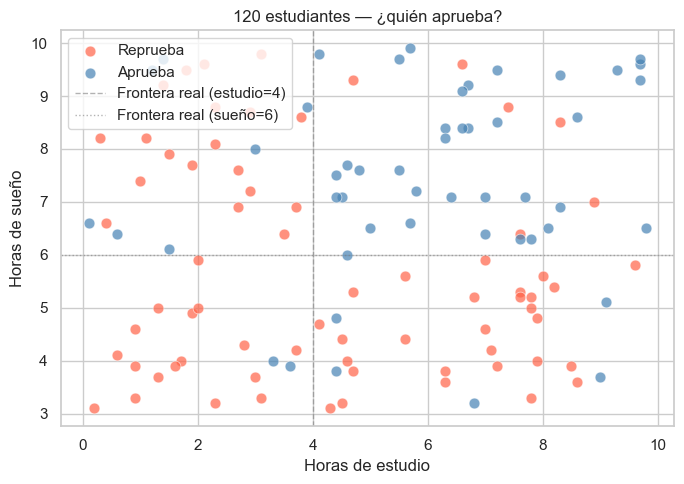

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

for cls, color, label in [(0, "tomato", "Reprueba"), (1, "steelblue", "Aprueba")]:
    mask = df["aprueba"] == cls
    ax.scatter(
        df.loc[mask, "horas_estudio"],
        df.loc[mask, "horas_sueno"],
        s=60, alpha=0.7, color=color, edgecolors="white", linewidth=0.5,
        label=label,
    )

ax.axvline(4, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="Frontera real (estudio=4)")
ax.axhline(6, color="gray", linestyle=":",  linewidth=1, alpha=0.6, label="Frontera real (sueño=6)")

ax.set_xlabel("Horas de estudio")
ax.set_ylabel("Horas de sueño")
ax.set_title("120 estudiantes — ¿quién aprueba?")
ax.legend()
plt.tight_layout()
plt.show()

## 2 · ¿Por qué el árbol corta donde corta? — Impureza Gini

El árbol busca el corte que deja los grupos **más puros** posibles.
"Puro" = todos del mismo color (todos aprueban o todos reprueban).

**Impureza Gini de un nodo:**

$$Gini = 1 - (p_{aprueba}^2 + p_{reprueba}^2)$$

- Gini = 0   → nodo 100 % puro (perfecto)
- Gini = 0.5 → nodo 50/50 (peor caso)

El árbol prueba todos los umbrales posibles en `horas_estudio` y `horas_sueno`
y elige el que minimiza el **Gini ponderado** de los dos grupos resultantes.

In [4]:
def gini(y):
    if len(y) == 0:
        return 0
    p = y.mean()
    return 1 - (p**2 + (1-p)**2)

def gini_ponderado(izq, der):
    n = len(izq) + len(der)
    return (len(izq)/n) * gini(izq) + (len(der)/n) * gini(der)

umbral = 4.0
izq = df.loc[df["horas_estudio"] <  umbral, "aprueba"].values
der = df.loc[df["horas_estudio"] >= umbral, "aprueba"].values

print(f"Corte: horas_estudio < {umbral}")
print(f"  Grupo izquierdo ({len(izq)} estudiantes) — Gini = {gini(izq):.3f}")
print(f"  Grupo derecho   ({len(der)} estudiantes) — Gini = {gini(der):.3f}")
print(f"  Gini ponderado  = {gini_ponderado(izq, der):.3f}")
print(f"\nGini del nodo raíz (sin cortar) = {gini(df['aprueba'].values):.3f}")

Corte: horas_estudio < 4.0
  Grupo izquierdo (45 estudiantes) — Gini = 0.320
  Grupo derecho   (75 estudiantes) — Gini = 0.496
  Gini ponderado  = 0.430

Gini del nodo raíz (sin cortar) = 0.486


## 3 · Tres árboles — una pregunta, dos o tres

Entrenamos el mismo árbol con distintas **profundidades máximas** (`max_depth`).
Cada nivel extra = una pregunta más que puede hacer el árbol.

| `max_depth` | Preguntas máximas | Riesgo |
|---|---|---|
| 1 | 1 | Demasiado simple — no ve toda la información |
| 2 | 3 | Equilibrio — captura la interacción estudio+sueño |
| 3 | 7 | Empieza a memorizar el ruido |

In [5]:
X = df[["horas_estudio", "horas_sueno"]].values
y = df["aprueba"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelos = {}
for depth in [1, 2, 3]:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    modelos[depth] = clf
    print(f"\n--- max_depth={depth} ---")
    print(export_text(clf, feature_names=["horas_estudio", "horas_sueno"]))


--- max_depth=1 ---
|--- horas_sueno <= 5.95
|   |--- class: 0
|--- horas_sueno >  5.95
|   |--- class: 1


--- max_depth=2 ---
|--- horas_sueno <= 5.95
|   |--- horas_estudio <= 8.80
|   |   |--- class: 0
|   |--- horas_estudio >  8.80
|   |   |--- class: 1
|--- horas_sueno >  5.95
|   |--- horas_estudio <= 3.95
|   |   |--- class: 0
|   |--- horas_estudio >  3.95
|   |   |--- class: 1


--- max_depth=3 ---
|--- horas_sueno <= 5.95
|   |--- horas_estudio <= 8.80
|   |   |--- horas_sueno <= 3.25
|   |   |   |--- class: 0
|   |   |--- horas_sueno >  3.25
|   |   |   |--- class: 0
|   |--- horas_estudio >  8.80
|   |   |--- horas_estudio <= 9.35
|   |   |   |--- class: 1
|   |   |--- horas_estudio >  9.35
|   |   |   |--- class: 0
|--- horas_sueno >  5.95
|   |--- horas_estudio <= 3.95
|   |   |--- horas_sueno <= 6.50
|   |   |   |--- class: 1
|   |   |--- horas_sueno >  6.50
|   |   |   |--- class: 0
|   |--- horas_estudio >  3.95
|   |   |--- horas_estudio <= 7.30
|   |   |   |--- cla

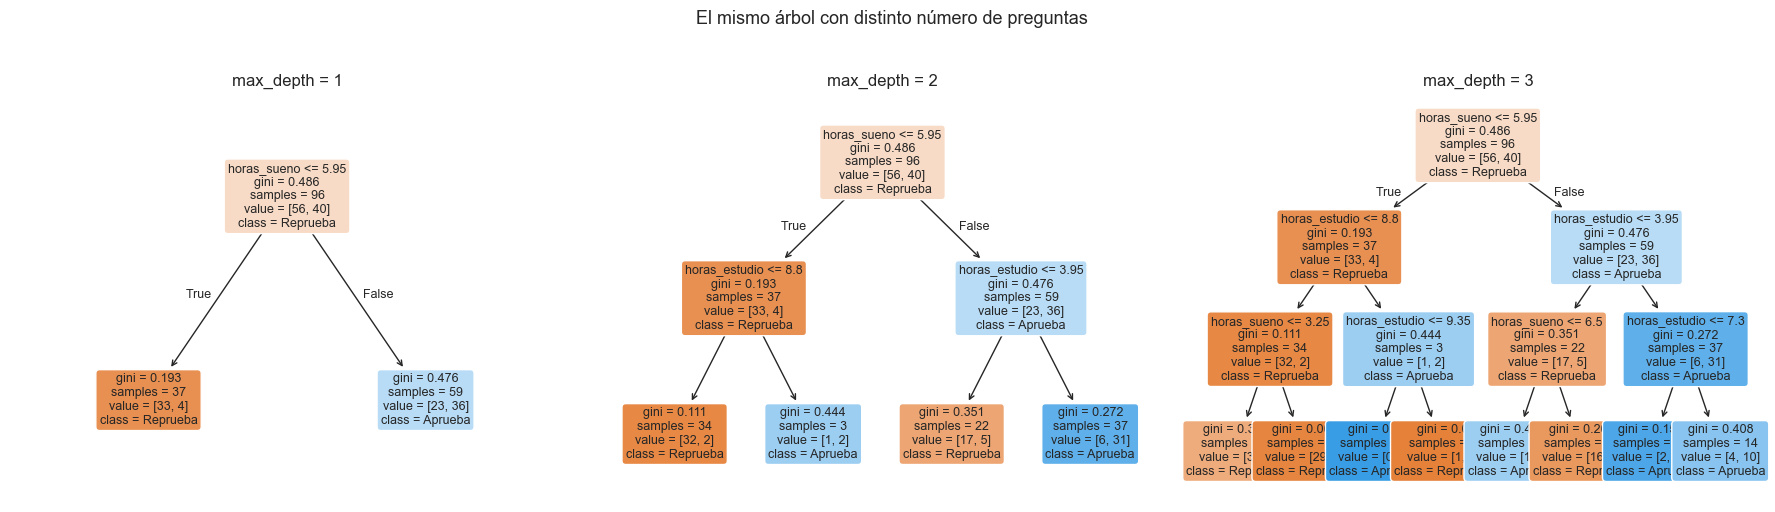

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, depth in zip(axes, [1, 2, 3]):
    plot_tree(
        modelos[depth],
        feature_names=["horas_estudio", "horas_sueno"],
        class_names=["Reprueba", "Aprueba"],
        filled=True,
        rounded=True,
        fontsize=9,
        ax=ax,
    )
    ax.set_title(f"max_depth = {depth}", fontsize=12)

plt.suptitle("El mismo árbol con distinto número de preguntas", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4 · ¿Cuál generaliza mejor? — Train vs Test

Un árbol que memoriza los datos de entrenamiento tiene accuracy alta en train
pero baja en test. Eso es **overfitting** (sobreajuste).

Un árbol demasiado simple tiene accuracy mediocre en ambos lados. Eso es
**underfitting** (subajuste).

In [7]:
rows = []
for depth in [1, 2, 3]:
    clf = modelos[depth]
    acc_train = accuracy_score(y_train, clf.predict(X_train))
    acc_test  = accuracy_score(y_test,  clf.predict(X_test))
    rows.append({
        "max_depth": depth,
        "acc_train": acc_train,
        "acc_test":  acc_test,
        "gap":       acc_train - acc_test,
    })

resultados = pd.DataFrame(rows)
resultados["acc_train"] = resultados["acc_train"].map("{:.1%}".format)
resultados["acc_test"]  = resultados["acc_test"].map("{:.1%}".format)
resultados["gap"]       = resultados["gap"].map("{:+.1%}".format)
resultados.columns      = ["max_depth", "Accuracy train", "Accuracy test", "Gap (train−test)"]
resultados

,max_depth,Accuracy train,Accuracy test,Gap (train−test)
0,1,71.9%,79.2%,-7.3%
1,2,85.4%,79.2%,+6.2%
2,3,87.5%,79.2%,+8.3%


**Lectura:**

- `max_depth=1` → accuracy baja en train Y test → **underfitting** (demasiado podado).
  Una sola pregunta no alcanza para capturar que el árbol necesita *ambas* condiciones.

- `max_depth=2` → buen balance. El árbol pregunta por estudio Y sueño.

- `max_depth=3` → accuracy perfecta en train, cae en test → **overfitting**.
  Empezó a memorizar los 15 % de estudiantes con etiquetas ruidosas.

## 5 · Nuevo estudiante — ¿aprueba?

Llega un estudiante que estudió **5 horas** y durmió **7 horas**.
¿Qué dice cada árbol?

In [8]:
nuevo = np.array([[5.0, 7.0]])

print("Nuevo estudiante: 5h estudio, 7h sueño\n")
for depth in [1, 2, 3]:
    pred  = modelos[depth].predict(nuevo)[0]
    proba = modelos[depth].predict_proba(nuevo)[0]
    label = "APRUEBA" if pred == 1 else "REPRUEBA"
    print(f"  max_depth={depth} -> {label}  (prob aprueba = {proba[1]:.0%})")

Nuevo estudiante: 5h estudio, 7h sueño

  max_depth=1 -> APRUEBA  (prob aprueba = 61%)
  max_depth=2 -> APRUEBA  (prob aprueba = 84%)
  max_depth=3 -> APRUEBA  (prob aprueba = 91%)


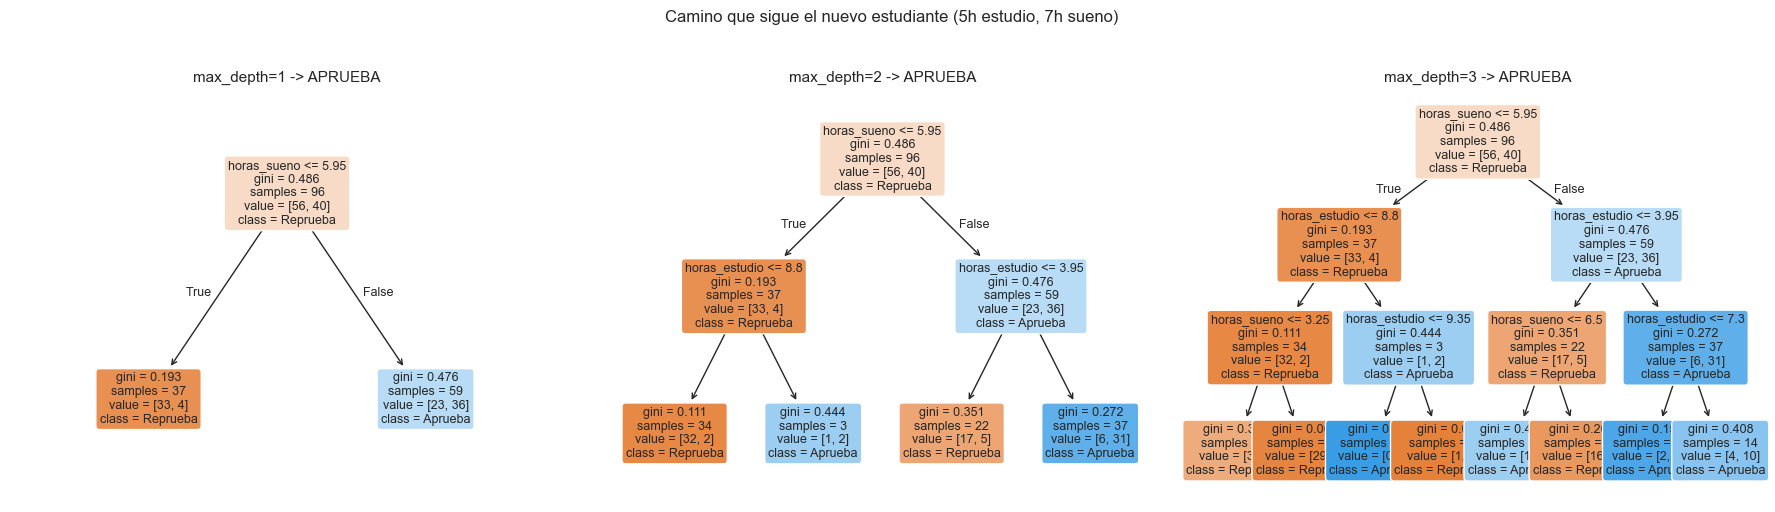

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, depth in zip(axes, [1, 2, 3]):
    plot_tree(
        modelos[depth],
        feature_names=["horas_estudio", "horas_sueno"],
        class_names=["Reprueba", "Aprueba"],
        filled=True, rounded=True, fontsize=9,
        ax=ax,
    )
    pred  = modelos[depth].predict(nuevo)[0]
    label = "APRUEBA" if pred == 1 else "REPRUEBA"
    ax.set_title(f"max_depth={depth} -> {label}", fontsize=11)

plt.suptitle("Camino que sigue el nuevo estudiante (5h estudio, 7h sueno)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 6 · Lo que sorprende de los árboles de decisión

### 1. Poda acepta equivocarse en entrenamiento a propósito

`max_depth=2` clasifica mal a algunos estudiantes del entrenamiento —
los 15 % con etiquetas ruidosas. Pero en datos nuevos rinde mejor que `max_depth=3`,
que los "aprendió de memoria". Aceptar error en train para ganar en test parece
contradictorio, pero es la clave de la generalización.

### 2. Grupos del mismo tamaño no son grupos puros

Si un corte divide 60 estudiantes en dos grupos de 30, pero ambos grupos
tienen 50 % de aprueba/reprueba, el Gini ponderado no mejora nada.
**Tamaño igual ≠ pureza igual.** El árbol busca pureza, no equilibrio.

### 3. Las interacciones emergen solas

Nadie le programó al árbol que "estudiar Y dormir" importan juntos.
Lo descubrió al encadenar splits: primero pregunta por estudio,
luego (en la rama correspondiente) pregunta por sueño.
La regla `estudio > 4 AND sueño > 6` emergió del proceso, no de una instrucción.

### 4. Los porcentajes mandan, no los conteos

Si un nodo tiene 65 estudiantes que reprueban y otro tiene 40 que reprueban,
el primero parece peor. Pero si el primer nodo tiene 130 estudiantes en total
(50 % reprueba) y el segundo tiene 45 (89 % reprueba), el segundo es el problema.
El árbol usa proporciones (Gini), nunca conteos absolutos.

## Resumen

| Concepto | Qué aprendimos |
|---|---|
| Split | El árbol hace preguntas sí/no sobre un umbral de una variable |
| Gini | Mide qué tan mezclados están los grupos; el árbol minimiza Gini |
| `max_depth=1` | Una pregunta — demasiado simple para capturar interacciones |
| `max_depth=2` | Sweet spot — captura "estudio Y sueño" con buen balance |
| `max_depth=3` | Memoriza el ruido — mejor en train, peor en test |
| Nuevo estudiante | 5h estudio + 7h sueño → Aprueba (los tres árboles coinciden) |

> **Regla práctica:** elegir `max_depth` por validación cruzada, no a ojo.
> El criterio es siempre el error en datos *no vistos*.